In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Sequential


In [5]:
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype('float32') / 127.5 - 1
x_train = np.expand_dims(x_train, axis=-1)

print(x_train.shape)

(60000, 28, 28, 1)


In [6]:
generator = Sequential([
    layers.Dense(128, input_dim=100),
    layers.LeakyReLU(0.2),
    layers.Dense(256),
    layers.LeakyReLU(0.2),
    layers.Dense(784, activation='tanh'),
    layers.Reshape((28, 28, 1))
])

generator.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       201,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 247,440 (966.56 KB)

 Trainable params: 247,440 (966.56 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
discriminator = Sequential([
    layers.Flatten(input_shape=(28, 28, 1)),
    layers.Dense(256),
    layers.LeakyReLU(0.2),
    layers.Dense(128),
    layers.LeakyReLU(0.2),
    layers.Dense(1, activation='sigmoid')
])

discriminator.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 233,985 (914.00 KB)

 Trainable params: 233,985 (914.00 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
discriminator.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [9]:
discriminator.trainable = False

gan = Sequential([generator, discriminator])

gan.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

In [10]:
epochs = 10000
batch_size = 128
half_batch = batch_size // 2

for epoch in range(epochs):

    # Train Discriminator
    idx = np.random.randint(0, x_train.shape[0], half_batch)
    real = x_train[idx]

    noise = np.random.normal(0, 1, (half_batch, 100))
    fake = generator.predict(noise, verbose=0)

    discriminator.trainable = True

    d_loss_real = discriminator.train_on_batch(
        real, np.ones((half_batch, 1))
    )
    d_loss_fake = discriminator.train_on_batch(
        fake, np.zeros((half_batch, 1))
    )

    d_loss = 0.5 * (
        np.array(d_loss_real) + np.array(d_loss_fake)
    )

    # Train Generator
    discriminator.trainable = False

    noise = np.random.normal(0, 1, (batch_size, 100))
    g_loss = gan.train_on_batch(
        noise, np.ones((batch_size, 1))
    )

    if epoch % 1000 == 0:
        print("Epoch:", epoch,
              "D Loss:", d_loss[0],
              "G Loss:", g_loss)

Epoch: 0 D Loss: 1.0620354 G Loss: 0.6783031
Epoch: 1000 D Loss: 0.15962088 G Loss: 5.998766
Epoch: 2000 D Loss: 0.160844 G Loss: 5.301931
Epoch: 3000 D Loss: 0.19222549 G Loss: 4.8656783
Epoch: 4000 D Loss: 0.22001727 G Loss: 4.4420667
Epoch: 5000 D Loss: 0.25262967 G Loss: 4.0664396
Epoch: 6000 D Loss: 0.2789669 G Loss: 3.7602222
Epoch: 7000 D Loss: 0.29691854 G Loss: 3.5441198
Epoch: 8000 D Loss: 0.3099199 G Loss: 3.3845758
Epoch: 9000 D Loss: 0.3219138 G Loss: 3.2461522


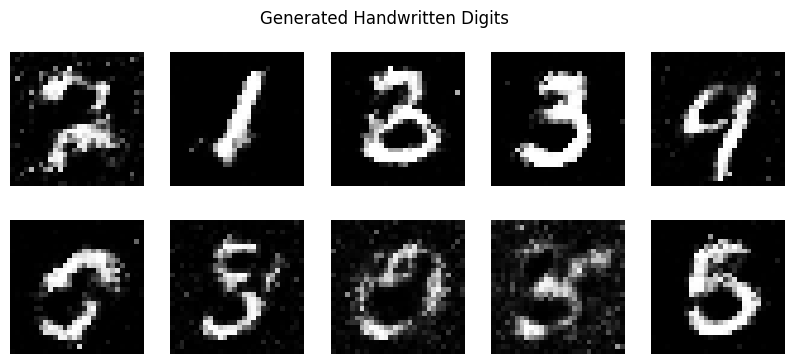

In [11]:
noise = np.random.normal(0, 1, (10, 100))
images = generator.predict(noise, verbose=0)

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i, :, :, 0], cmap='gray')
    plt.axis('off')

plt.suptitle("Generated Handwritten Digits")
plt.show()